In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [2]:
# --------------------------------------------------
# Load predictor dataset
# --------------------------------------------------
X_df = pd.read_parquet(
    "../data/denver_tract_dataset.parquet"
)

print("Predictor shape:", X_df.shape)
print(X_df.head())


Predictor shape: (178, 12)
         GEOID  total_population  median_income  population_density  \
0  08031002101              3238       116667.0         2171.817195   
1  08031004404              5961        63966.0         2699.468191   
2  08031004403              3965        81500.0         1597.709522   
3  08031003701              3782        94402.0         1120.123600   
4  08031003702              5037        71063.0         4212.613372   

   pct_under_18  pct_over_65  pct_bachelors_degree  employment_rate  \
0      0.046634     0.059914              0.689031         0.970855   
1      0.207516     0.048482              0.295493         0.877747   
2      0.138714     0.100883              0.433739         0.944488   
3      0.176097     0.154680              0.806408         0.983641   
4      0.085964     0.082390              0.754315         0.946168   

   poverty_rate  road_density  intersection_density  transit_stop_density  
0      0.123224     24.679482             3

In [3]:
# --------------------------------------------------
# Load target dataset
# --------------------------------------------------
y_df = pd.read_parquet(
    "../data/accessibility/accessibility_state-CO_counties-031_year-2023_thresholds-15-30-45-60.parquet"
)

print("Target shape:", y_df.shape)
print(y_df.head())


Target shape: (178, 5)
       from_id  jobs_15min  jobs_30min  jobs_45min  jobs_60min
0  08031002101     52609.0    277690.0      372564      438107
1  08031004404     11294.0     50630.0      130851      361771
2  08031004403      8303.0     51016.0      133606      359669
3  08031003701     23555.0    205923.0      352646      436260
4  08031003702     48193.0    222534.0      370577      440521


In [4]:
# --------------------------------------------------
# Merge predictors + target
# --------------------------------------------------
df = X_df.merge(
    y_df,
    left_on="GEOID",
    right_on="from_id",
    how="inner"
)

print("Merged shape:", df.shape)
print(df.head(2))

Merged shape: (178, 17)
         GEOID  total_population  median_income  population_density  \
0  08031002101              3238       116667.0         2171.817195   
1  08031004404              5961        63966.0         2699.468191   

   pct_under_18  pct_over_65  pct_bachelors_degree  employment_rate  \
0      0.046634     0.059914              0.689031         0.970855   
1      0.207516     0.048482              0.295493         0.877747   

   poverty_rate  road_density  intersection_density  transit_stop_density  \
0      0.123224     24.679482             35.548583              5.365824   
1      0.239557     23.916024             39.851233              4.981404   

       from_id  jobs_15min  jobs_30min  jobs_45min  jobs_60min  
0  08031002101     52609.0    277690.0      372564      438107  
1  08031004404     11294.0     50630.0      130851      361771  


In [5]:
# --------------------------------------------------
# Define target variable
# --------------------------------------------------
TARGET = "jobs_30min"

In [6]:
# --------------------------------------------------
# Define feature columns
# --------------------------------------------------
feature_cols = [

    "total_population",
    "median_income",
    "population_density",

    "pct_under_18",
    "pct_over_65",

    "pct_bachelors_degree",

    "employment_rate",
    "poverty_rate",

    "road_density",
    "intersection_density",
    "transit_stop_density"
]

X = df[feature_cols].copy()

y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (178, 11)
y shape: (178,)


In [7]:
# --------------------------------------------------
# Train / test split
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 142
Test size: 36


In [8]:
# --------------------------------------------------
# XGBoost model
# --------------------------------------------------
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [9]:
# --------------------------------------------------
# Train model
# --------------------------------------------------
model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [10]:
# --------------------------------------------------
# Predictions
# --------------------------------------------------
y_pred = model.predict(X_test)

In [11]:
# --------------------------------------------------
# Evaluation
# --------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-----------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")


Model Performance
-----------------
MAE  : 40,612.35
RMSE : 49,752.28
R²   : 0.7565


In [12]:
# --------------------------------------------------
# Feature importance
# --------------------------------------------------
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print("\nFeature Importance")
print("------------------")
print(importance_df)


Feature Importance
------------------
                 feature  importance
3           pct_under_18    0.277304
5   pct_bachelors_degree    0.155122
8           road_density    0.111978
2     population_density    0.093327
7           poverty_rate    0.088168
10  transit_stop_density    0.081538
4            pct_over_65    0.058463
9   intersection_density    0.050055
1          median_income    0.034161
0       total_population    0.028347
6        employment_rate    0.021539


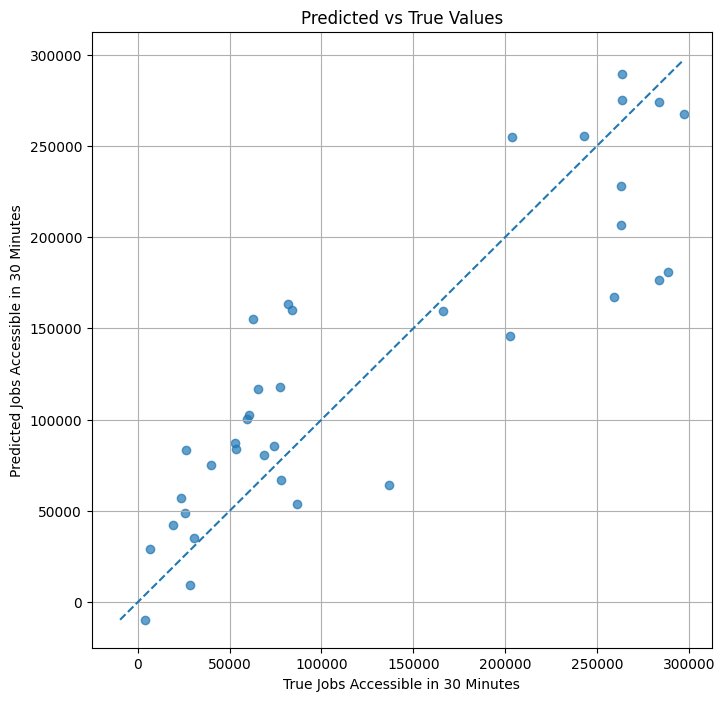

In [13]:
# %%
import matplotlib.pyplot as plt

# %%
# --------------------------------------------------
# Predicted vs True Plot
# --------------------------------------------------
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

# perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("True Jobs Accessible in 30 Minutes")
plt.ylabel("Predicted Jobs Accessible in 30 Minutes")

plt.title("Predicted vs True Values")

plt.grid(True)

plt.show()